## Problem 3: Basic LP
#### (a)(b)(c)
Extreme Point: (2,1)(0,2)(0,0)
for (c), by objectiove function approach, the optimal solution is P_1:(2,1)

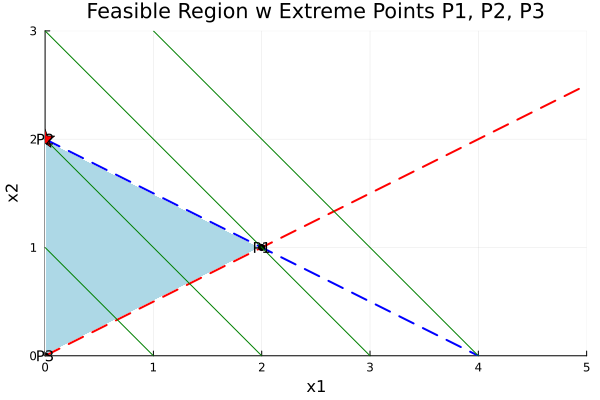

In [8]:
using Plots; gr()

# Define the constraint functions
f(x, y) = x + 2 * y - 4      # Corresponds to x1 + 2x2 <= 4
g(x, y) = x - 2 * y          # Corresponds to x1 - 2x2 <= 0

# Define a function that returns 1 within the feasible region, NaN outside
θ(x, y) = (f(x, y) <= 0) & (g(x, y) <= 0) & (x >= 0) & (y >= 0) ? 1 : NaN

# Set up grid for x1 and x2 (with appropriate range)
x = y = LinRange(0, 5, 1000)

# Plot the feasible region using contourf (filled contours)
contourf(x, y, θ, c = palette([:white, :lightblue]), legend=false, ratio=1, xlims=(0, 5), ylims=(0, 3))

# Plot the constraint boundaries
plot!(x, (4 .- x) ./ 2, label="x1 + 2*x2 = 4", lw=2, color=:blue, linestyle=:dash)  # Extend x1 + 2*x2 = 4
plot!(x, x ./ 2, label="x1 - 2*x2 = 0", lw=2, color=:red, linestyle=:dash)          # Extend x1 - 2*x2 = 0

# Add labels for extreme points
scatter!([2, 0, 0], [1, 2, 0], label=false, color=:black)  # Plot extreme points
annotate!([(2, 1, text("P1", :black, 10)),
           (0, 2, text("P2", :black, 10)),
           (0, 0, text("P3", :black, 10))])

# Add labels and limits
xlabel!("x1")
ylabel!("x2")
title!("Feasible Region w Extreme Points P1, P2, P3")

# Define level sets of the objective function (x1 + x2 = k) for different values of k
k_values = [-1, 0, 1, 2, 3, 4]  # Adjust these values to see the parallel level sets

# Plot the parallel level sets of the objective function
for k in k_values
    plot!(x, k .- x, label="x1 + x2 = $k", lw=1, color=:green, linestyle=:solid)
end

# Highlight the optimal solution (where the objective function is minimized)
scatter!([0], [2], label="Optimal Solution", color=:red, marker=:star, ms=10)


## Problem 5: Ellen Grunbaum returns

In [2]:
using JuMP
using Gurobi
using DataFrames

#### (c)

In [3]:
s = [3000, 200, 200, 1500, 600, 500, 1200, 400, 200, 2100]
q = [50, 73, 40, 80, 140, 60, 82, 24, 100, 33]
p = [70, 60, 42, 65, 160, 60, 57, 50, 102, 45]
r = [75, 65, 40, 85, 170, 60, 68, 55, 100, 50]
n = length(s)

M = 10^6
C = 100000

100000

In [4]:
model1 = Model(Gurobi.Optimizer)

# Variables: x (continuous), z (binary)
@variable(model1, 0 <= x[i=1:n] <= s[i])
@variable(model1, z, Bin)

@objective(model1, Max, 
    sum(0.99 * p[i] * x[i] + 0.98 * r[i] * (s[i] - x[i]) for i in 1:n) - sum(0.15 * (p[i] - q[i]) * x[i] for i in 1:n) * z
)

@constraint(model1, sum(0.99 * p[i] * x[i] for i in 1:n) - sum(0.15 * (p[i] - q[i]) * x[i] for i in 1:n) * z >= C)

@constraint(model1, sum((p[i] - q[i]) * x[i] for i in 1:n) <= M * z)
@constraint(model1, -sum((p[i] - q[i]) * x[i] for i in 1:n) <= M * (1 - z))

optimize!(model1)

Set parameter Username
Academic license - for non-commercial use only - expires 2025-08-19
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (mac64[x86] - Darwin 24.0.0 24A335)

CPU model: Intel(R) Core(TM) i5-8279U CPU @ 2.40GHz
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 2 rows, 11 columns and 20 nonzeros
Model fingerprint: 0x30619907
Model has 9 quadratic objective terms
Model has 1 quadratic constraint
Variable types: 10 continuous, 1 integer (1 binary)
Coefficient statistics:
  Matrix range     [2e+00, 1e+06]
  QMatrix range    [3e-01, 4e+00]
  QLMatrix range   [4e+01, 2e+02]
  Objective range  [6e-01, 2e+01]
  QObjective range [6e-01, 8e+00]
  Bounds range     [2e+02, 3e+03]
  RHS range        [1e+06, 1e+06]
  QRHS range       [1e+05, 1e+05]
Found heuristic solution: objective 642633.00000
Presolve removed 0 rows and 1 columns
Presolve time: 0.00s
Presolved: 17 rows, 27 columns, 74 nonzeros
Presolved model has 8 SOS constraint

In [5]:
optimal_x = value.(x)
optimal_z = value.(z)

# (i)
println("Objective value: ", objective_value(model1))

# (ii)
println("Optimal x values: ", optimal_x)

# (iii)
# Total capital gains and total tax
total_capital_gains = sum((p[i] - q[i]) * value(x[i]) for i in 1:n) * value(z)
total_capital_gains_tax = 0.15 * total_capital_gains

println("Total Capital Gains: ", total_capital_gains)
println("Total Capital Gains Tax: ", total_capital_gains_tax)

Objective value: 718063.9279279279
Optimal x values: [0.0, 200.0, 200.0, 0.0, 190.72072072072075, 500.0, 0.0, 0.0, 200.0, 0.0]
Total Capital Gains: 2014.4144144144148
Total Capital Gains Tax: 302.1621621621622


#### (f)

In [9]:
base_income = 140000
C = 100000
model2 = Model(Gurobi.Optimizer)

# Variables: x (continuous), z (binary), I (income), and T (tax)
@variable(model2, 0 <= x[i=1:n] <= s[i])
@variable(model2, I >= base_income)
@variable(model2, T >= 0)

# Total income constraint
@constraint(model2, I == base_income + sum((p[i] - q[i]) * x[i] for i in 1:n))

# Tax constraints (piecewise linear)
@constraint(model2, T >= 0.24 * (I - base_income))
@constraint(model2, T >= 0.24 * (160000 - base_income) + 0.32 * (I - 160000))
@constraint(model2, T >= 0.24 * (160000 - base_income) + 0.32 * 40000 + 0.35 * (I - 200000))
@constraint(model2, T >= 0.24 * (160000 - base_income) + 0.32 * 40000 + 0.35 * 330000 + 0.37 * (I - 530000))

# Minimum profit constraint
profit_constraint = @constraint(model2, sum(0.99 * p[i] * x[i] for i in 1:n) - T >= C)

@objective(model2, Max, sum(0.99 * p[i] * x[i] + 0.98 * r[i] * (s[i] - x[i]) for i in 1:n)- T)

optimize!(model2)

optimal_x = value.(x)
optimal_I = value(I)
optimal_T = value(T)

println("Optimal x values: ", optimal_x)
println("Total Income: ", optimal_I)
println("Tax: ", optimal_T)
println("Objective value: ", objective_value(model2))

# capital gains
total_capital_gains = optimal_I - base_income
println("Total Realized Capital Gains: ", total_capital_gains)

# tax
total_capital_gains_tax = optimal_T
println("Total Capital Gains Tax: ", total_capital_gains_tax)

Set parameter Username
Academic license - for non-commercial use only - expires 2025-08-19
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (mac64[x86] - Darwin 24.0.0 24A335)

CPU model: Intel(R) Core(TM) i5-8279U CPU @ 2.40GHz
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 6 rows, 12 columns and 29 nonzeros
Model fingerprint: 0xf70989f7
Coefficient statistics:
  Matrix range     [2e-01, 2e+02]
  Objective range  [6e-01, 2e+01]
  Bounds range     [2e+02, 1e+05]
  RHS range        [3e+04, 1e+05]
Presolve removed 0 rows and 1 columns
Presolve time: 0.00s
Presolved: 6 rows, 11 columns, 28 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    7.2079000e+05   3.504688e+02   0.000000e+00      0s
       2    7.1793334e+05   0.000000e+00   0.000000e+00      0s

Solved in 2 iterations and 0.00 seconds (0.00 work units)
Optimal objective  7.179333437e+05

User-callback calls 45, time in user-callback 0.00 sec
Op

#### (g)

In [10]:
C = 500000
model2 = Model(Gurobi.Optimizer)

# Variables: x (continuous), z (binary), I (income), and T (tax)
@variable(model2, 0 <= x[i=1:n] <= s[i])
@variable(model2, I >= base_income)
@variable(model2, T >= 0)

# Total income constraint
@constraint(model2, I == base_income + sum((p[i] - q[i]) * x[i] for i in 1:n))

# Tax constraints (piecewise linear)
@constraint(model2, T >= 0.24 * (I - base_income))
@constraint(model2, T >= 0.24 * (160000 - base_income) + 0.32 * (I - 160000))
@constraint(model2, T >= 0.24 * (160000 - base_income) + 0.32 * 40000 + 0.35 * (I - 200000))
@constraint(model2, T >= 0.24 * (160000 - base_income) + 0.32 * 40000 + 0.35 * 330000 + 0.37 * (I - 530000))

# Minimum profit constraint
profit_constraint = @constraint(model2, sum(0.99 * p[i] * x[i] for i in 1:n) - T >= C)

@objective(model2, Max, sum(0.99 * p[i] * x[i] + 0.98 * r[i] * (s[i] - x[i]) for i in 1:n) - T)

optimize!(model2)

optimal_x = value.(x)
optimal_I = value(I)
optimal_T = value(T)

println("Optimal x values: ", optimal_x)
println("Total Income: ", optimal_I)
println("Tax: ", optimal_T)
println("Objective value: ", objective_value(model2))

# capital gains
total_capital_gains = optimal_I - base_income
println("Total Realized Capital Gains: ", total_capital_gains)

# tax
total_capital_gains_tax = optimal_T
println("Total Capital Gains Tax: ", total_capital_gains_tax)

Set parameter Username
Academic license - for non-commercial use only - expires 2025-08-19
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (mac64[x86] - Darwin 24.0.0 24A335)

CPU model: Intel(R) Core(TM) i5-8279U CPU @ 2.40GHz
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 6 rows, 12 columns and 29 nonzeros
Model fingerprint: 0xfc143fca
Coefficient statistics:
  Matrix range     [2e-01, 2e+02]
  Objective range  [6e-01, 2e+01]
  Bounds range     [2e+02, 1e+05]
  RHS range        [3e+04, 5e+05]
Presolve removed 0 rows and 1 columns
Presolve time: 0.00s
Presolved: 6 rows, 11 columns, 28 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    6.9741398e+05   1.034197e+04   0.000000e+00      0s
       6    6.6453253e+05   0.000000e+00   0.000000e+00      0s

Solved in 6 iterations and 0.00 seconds (0.00 work units)
Optimal objective  6.645325296e+05

User-callback calls 48, time in user-callback 0.00 sec
Op